In [3]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

proc/Run
not count averaged
[-5.51316517e-02  5.43071487e+02]
[-5.51316517e-02  5.43071487e+02]


KeyError: 'scanvar_on'

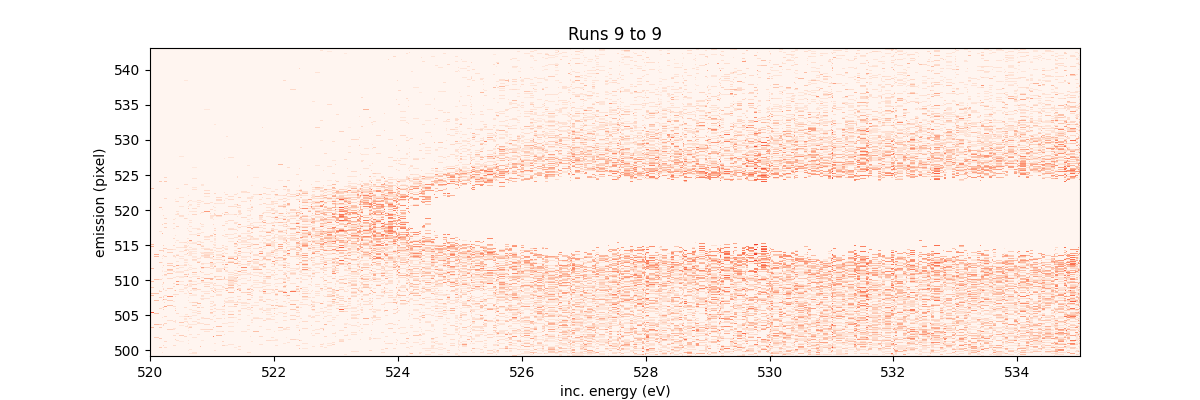

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 6
runs=[22,23,26,27,29,30,31,32]#[22,23,26,27,29,30,31,32] #[22,23,24,26,27,29,30,31,32]
#[112,113,114,116,117,120,121,122,123] 106
# runs = [145,147,148,149,150,152,154,156,157,158,160,161]

exp = 'rix101331225'


fyaml = '../roi_inputTT.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True,scantype='mono_fly')

avg.plot_svls2D(figsize=(12,4),savefig=True,calibrated=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=True)
avg.plot_svls1D(figsize=(12,4))

avg.save_avg()


In [4]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'

bgrun=6
run = 9

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
proc = Reduced(fname,bgname,fyaml,bgyaml)
# bg = SmallData(bgname, bgyaml)

<KeysViewHDF5 ['mono_ev', 'mono_g_pi', 'step_value']>
9
setting up properties
dataset prop <functools.cached_property object at 0x7fe7d44a43d0>
dataset prop <functools.cached_property object at 0x7fe7d44a4090>
dataset prop <functools.cached_property object at 0x7fe7d6121990>
dataset prop <functools.cached_property object at 0x7fe7d44a4410>
dataset prop <functools.cached_property object at 0x7fe7d44a49d0>
dataset prop <functools.cached_property object at 0x7fe7d44a4c90>
dataset prop <functools.cached_property object at 0x7fe7d44a4b90>
dataset prop <functools.cached_property object at 0x7fe7d44a4fd0>
6
setting up properties
dataset prop <functools.cached_property object at 0x7fe7d44a5a90>
dataset prop <functools.cached_property object at 0x7fe7d44a5e90>
dataset prop <functools.cached_property object at 0x7fe7e5299190>
dataset prop <functools.cached_property object at 0x7fe7d44a6210>
dataset prop <functools.cached_property object at 0x7fe7d44a5c50>
dataset prop <functools.cached_property 

NameError: name 'avg' is not defined

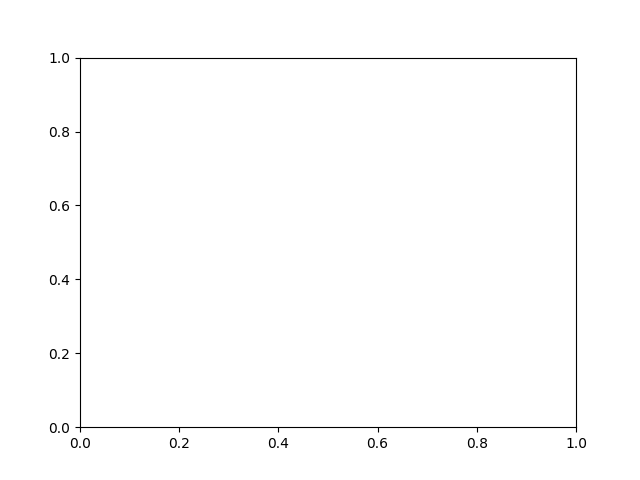

In [5]:
fig,ax=plt.subplots(1,1)
ax.pcolor(avg.average['scanvar'],np.arange(avg.average['axis_svls_mean'].shape[1]),(avg.average['axis_svls_mean'].T))

In [ ]:
avg.emi_calibration([521,400], [534,164],
                                    width_pixels=10,
                                    plot_on=True,
                                    use='')

NameError: name 'avg' is not defined

In [24]:
calibrated_axis, (a, b), details = elastic_calibrate_from_two_points(
                                    avg.average['scanvar'],
                                    avg.average['axis_svls_mean'],
                                    [395,314], [401,142],
                                    width_pixels=10,
                                    plot_on=True
                                 )

NameError: name 'elastic_calibrate_from_two_points' is not defined

In [11]:
(a,b)

(-0.0366449869656799, 400.5108021860192)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [4]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0061.h5'


with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls'].keys())
    test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    # ax.plot(np.nanmean(file['intg']['axis_svls']['curve_corr_corrected_image'],axis=0))
    # fh = h5py.File(fname, 'r')
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]
plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()

<KeysViewHDF5 ['count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_milliJoulesPerPulse_sevr', 'lightStatus_sum_laser', 'lightStatus_sum

KeyError: "Unable to synchronously open object (object 'curve_corr_corrected_image' doesn't exist)"

In [10]:
test_ims_thresh.sum()

0.0

In [25]:
run=9
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp.keys())

<KeysViewHDF5 ['crix_w8', 'epics_archiver', 'lightStatus', 'mono_hrencoder', 'rix_fim0', 'rix_fim1', 'scan', 'timestamp', 'timing']>


In [9]:
run=23
fname = f'./avg/Run0022to0023.h5'
with h5py.File(fname) as tmp:
    print(tmp['E_trans_off'][:])

[-20.744991   -20.54499    -20.34499    -20.14499    -19.94499
 -19.744991   -19.54499    -19.34499    -19.14499    -18.94499
 -18.744991   -18.54499    -18.34499    -18.14499    -17.94499
 -17.744991   -17.54499    -17.34499    -17.14499    -16.94499
 -16.744991   -16.54499    -16.34499    -16.14499    -15.944991
 -15.74499    -15.544991   -15.344991   -15.144991   -14.944991
 -14.74499    -14.544991   -14.344991   -14.144991   -13.944991
 -13.74499    -13.544991   -13.344991   -13.144991   -12.944991
 -12.74499    -12.544991   -12.344991   -12.144991   -11.944991
 -11.74499    -11.544991   -11.344991   -11.144991   -10.944991
 -10.74499    -10.544991   -10.344991   -10.144991    -9.944991
  -9.74499     -9.544991    -9.344991    -9.144991    -8.944991
  -8.74499     -8.544991    -8.344991    -8.144991    -7.9449906
  -7.744991    -7.5449905   -7.3449907   -7.144991    -6.9449906
  -6.744991    -6.5449905   -6.3449907   -6.144991    -5.9449906
  -5.744991    -5.5449905   -5.3449907   

In [ ]:

# def avg_data(runs : list, proc_folder : str = '',proc_path : str = ''):
runs=[23,26]
proc_folder = './proc/Run'
avg = {}
with h5py.File(proc_folder+f'{runs[0]:04d}.h5','r') as tmp:
    keys = list(tmp.keys())
    if 'counts_on' in keys:
        counts_on = np.zeros(tmp['counts_on'].shape)
        counts_off = np.zeros(tmp['counts_off'].shape)
        laser = True
    else:
        counts = np.zeros(tmp['counts'].shape)
        laser = False

    # print(keys)
    for key in keys:
        avg[key] = np.zeros(tmp[key].shape)

i=0
for run in runs:
    i=i+1
    file = proc_folder+f'{run:04d}.h5'
    # FIXME:     
    with h5py.File(file,'r') as f:
        print(np.asarray(f['scanvar_off']))
        if laser:
            count_on = np.asarray(f['counts_on'])
            count_off = np.asarray(f['counts_off'])
            print(count_off)
            laser = True
        else:
            count = np.asarray(f['counts'])

        for key in keys:
            if laser:
                if 'on' in key:
                    count = count_on
                elif 'off' in key:
                    count = count_off
            else:
                count = count

            if avg[key].shape==f[key].shape:
                if len(avg[key].shape) == 1:
                    avg[key] = avg[key] + np.asarray(f[key])*count
                else:
                    avg[key] = avg[key] + np.asarray(f[key])*count[:,np.newaxis]
                # print(f[key])
            else:
                print(f'shape0 {avg[key].shape} shape1 {f[key].shape}')
                #FIXME: Here implement stuff for stitching
                print(f'Run {run} {key} shapes do not match')
    if laser:
        counts_on = counts_on + count_on
        counts_off = counts_off + count_off

    else:
        counts = counts + count
        
for key in keys:
    if laser:
        if 'on' in key:
            if len(avg[key].shape) == 1:
                avg[key] = avg[key]/counts_on
            else:
                avg[key] = avg[key]/counts_on[:,np.newaxis]
        elif 'off' in key:
            if len(avg[key].shape) == 1:
                avg[key] = avg[key]/counts_off
            else:
                avg[key] = avg[key]/counts_off[:,np.newaxis]
    else:
        if len(avg[key].shape) == 1:
            avg[key] = avg[key]/counts
        else:
            avg[key] = avg[key]/counts[:,np.newaxis]
    # return avg
    

[521.11536 521.3461  521.5769  521.8077  522.03845 522.2692  522.5
 522.7308  522.96155 523.1923  523.4231  523.6539  523.88464 524.11536
 524.3461  524.5769  524.8077  525.03845 525.2692  525.5     525.7308
 525.96155 526.1923  526.4231  526.6539  526.88464 527.11536 527.3461
 527.5769  527.8077  528.03845 528.2692  528.5     528.7308  528.96155
 529.1923  529.4231  529.6539  529.88464]
[249. 144. 143. 147. 153. 168. 130. 161. 139. 150. 148. 156. 146. 139.
 150. 145. 148. 141. 158. 138. 151. 144. 141. 140. 148. 140. 145. 148.
 143. 143. 142. 146. 118.  72. 125. 146. 136. 150. 142.]
[521.11536 521.3461  521.5769  521.8077  522.03845 522.2692  522.5
 522.7308  522.96155 523.1923  523.4231  523.6539  523.88464 524.11536
 524.3461  524.5769  524.8077  525.03845 525.2692  525.5     525.7308
 525.96155 526.1923  526.4231  526.6539  526.88464 527.11536 527.3461
 527.5769  527.8077  528.03845 528.2692  528.5     528.7308  528.96155
 529.1923  529.4231  529.6539  529.88464]
[160. 140. 144. 158

In [19]:
run=23
file = proc_folder+f'{run:04d}.h5'
# FIXME:     
f1= h5py.File(file,'r')

run=26
file = proc_folder+f'{run:04d}.h5'
# FIXME:     
f2= h5py.File(file,'r')

x1 =np.asarray(f1['scanvar_off'])
c1 =np.asarray(f1['counts_off'])
x2 =np.asarray(f2['scanvar_off'])
c2 =np.asarray(f2['counts_off'])

(x1*c1+x2*c2)/(c1+c2)
c1+c2

array([409., 284., 287., 305., 298., 320., 277., 310., 286., 306., 292.,
       307., 291., 275., 304., 292., 293., 295., 298., 279., 305., 285.,
       280., 292., 285., 290., 287., 294., 282., 295., 274., 299., 256.,
       218., 262., 293., 281., 295., 287.], dtype=float32)

array([521.11536, 521.3462 , 521.5769 , 521.8077 , 522.0385 , 522.2692 ,
       522.5    , 522.7308 , 522.96155, 523.1923 , 523.42303, 523.6539 ,
       523.88464, 524.11536, 524.3461 , 524.5769 , 524.8077 , 525.03845,
       525.2692 , 525.5    , 525.7307 , 525.9615 , 526.1923 , 526.4231 ,
       526.6538 , 526.88464, 527.11536, 527.34607, 527.5769 , 527.8077 ,
       528.03845, 528.2692 , 528.5    , 528.7308 , 528.9616 , 529.1923 ,
       529.4231 , 529.6539 , 529.88464], dtype=float32)

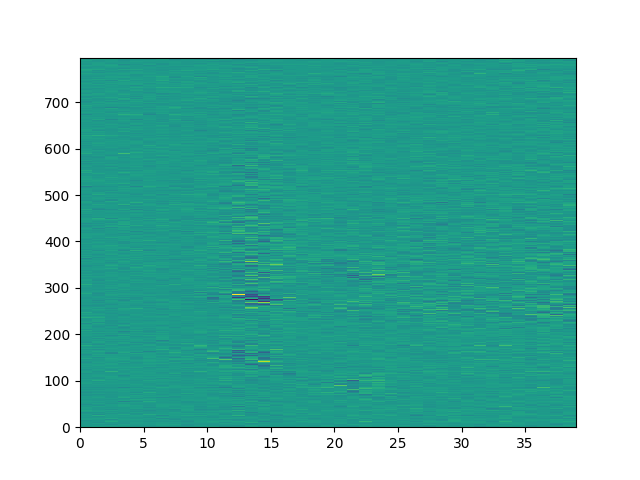

In [25]:
fig,ax=plt.subplots(1,1)
ax.pcolor(avg['axis_svls_on_mean'].T-avg['axis_svls_off_mean'].T)